In [1]:
import cv2
import numpy as np
from scipy.special import comb

A partir de là

In [180]:
import cv2
import numpy as np

# Charger l'image
img = cv2.imread("train.webp", cv2.IMREAD_GRAYSCALE)

img_h, img_w = img.shape[:2]
print(f"Dimensions de l'image : {img_w}x{img_h}")
# Créer le détecteur LSD
lsd = cv2.createLineSegmentDetector(0)

# Détecter les lignes
lines, widths, precisions, _ = lsd.detect(img)

# lines est un tableau (N, 1, 4) : x1,y1,x2,y2
lines = lines[:,0,:]  # pour simplifier

print(f"{len(lines)} segments détectés")

Dimensions de l'image : 450x400
656 segments détectés


In [ ]:
import numpy as np
from scipy.stats import binom
#M+A
# -----------------------------
# Fonctions utilitaires
# -----------------------------
def segment_orientation(line):
    x1, y1, x2, y2 = line
    return np.arctan2(y2 - y1, x2 - x1)

def segment_length(line):
    x1, y1, x2, y2 = line
    return np.hypot(x2 - x1, y2 - y1)

def sample_endpoints(segments):
    """Retourne tous les endpoints des segments Nx4 -> 2N x 2"""
    return np.vstack([segments[:, :2], segments[:, 2:]])

# def count_points_in_box(points, x_edges, y_edges):
#     b = 0
#     for i in range(len(x_edges)-1):
#         for j in range(len(y_edges)-1):
#             if np.any((points[:,0] >= x_edges[i]) & (points[:,0] < x_edges[i+1]) &
#                       (points[:,1] >= y_edges[j]) & (points[:,1] < y_edges[j+1])):
#                 b += 1
#     return b
def count_points_in_box(points, pt1, pt2, rect_w, c):
    """
    CORRECTION : Projection longitudinale selon la section 2.1 du papier.
    Au lieu d'une grille 2D, on divise le rectangle r en c boîtes 
    le long de son axe principal.
    """
    # 1. Calcul du vecteur directeur et de la longueur du rectangle r
    vec = pt2 - pt1
    L = np.hypot(vec[0], vec[1])
    if L < 1e-10: return 0
    
    # Vecteurs unitaires : u (longitudinal) et v (transversal/orthogonal)
    u = vec / L
    v = np.array([-u[1], u[0]])

    # 2. Projection des points dans le repère local du rectangle
    # pts_rel : coordonnées relatives à pt1
    pts_rel = points - pt1
    # proj_u : position le long du segment [0, L]
    # proj_v : distance latérale par rapport à l'axe [-rect_w/2, rect_w/2]
    proj_u = pts_rel @ u
    proj_v = pts_rel @ v

    # 3. Filtrage des points à l'intérieur du rectangle r
    mask = (proj_u >= 0) & (proj_u <= L) & (np.abs(proj_v) <= rect_w / 2)
    points_in_rect = proj_u[mask]

    if len(points_in_rect) == 0:
        return 0

    # 4. Division en c boîtes égales et comptage des boîtes occupées (b)
    # On crée c intervalles sur la longueur L
    bins = np.linspace(0, L, c + 1)
    hist, _ = np.histogram(points_in_rect, bins=bins)
    
    # b est le nombre de boîtes contenant au moins un point (occupées)
    b = np.count_nonzero(hist)
    
    return b

def compute_p(box_area, R_area, N_R):
    q = box_area / R_area
    return 1 - (1 - q) ** N_R

def compute_B_tail(c, b, p):
    return binom.sf(b-1, c, p)

def compute_logNFA(b, c, p, N, W, L, C):
    log_B = np.log(compute_B_tail(c, b, p))
    log_N_tests = np.log(N*(N-1)/2) + np.log(W) + np.log(L) + np.log(C)
    return log_N_tests + log_B

# -----------------------------
# Point Alignment Detector complet
# -----------------------------
# def point_alignment_detector(points, R_area, box_area, c_list=[6], W=3, L=3, C=1, epsilon=1):
    N = len(points)
    alignments = []

    for i in range(N):
        for j in range(i+1, N):
            pt1, pt2 = points[i], points[j]
            best_logNFA = np.inf
            best_pair = None

            # Boucle sur W largeurs différentes
            for w_factor in np.linspace(0.5, 1.5, W):
                dx, dy = pt2 - pt1
                x_center, y_center = (pt1 + pt2)/2
                rect_length = np.hypot(dx, dy)
                rect_w = rect_length * w_factor

                # Boucle sur L positions locales
                for l_shift in np.linspace(-rect_length/4, rect_length/4, L):
                    x_shifted = x_center + l_shift
                    y_shifted = y_center + l_shift  # approximation simple

                    # Boucle sur C valeurs de c
                    for c in c_list:
                        x_edges = np.linspace(x_center - rect_w/2, x_center + rect_w/2, c+1)
                        y_edges = np.linspace(y_center - rect_w/2, y_center + rect_w/2, c+1)
                        b_obs = count_points_in_box(points, x_edges, y_edges)

                        N_R = N  # simplification : tous les points dans R
                        p = compute_p(box_area, R_area, N_R)

                        lognfa = compute_logNFA(b_obs, c, p, N, W, L, C)
                        if lognfa < best_logNFA:
                            best_logNFA = lognfa
                            best_pair = [pt1, pt2]

            # Garde l'alignement si NFA <= epsilon
            if best_logNFA <= np.log(epsilon):
                alignments.append(best_pair)

    return alignments

'''def point_alignment_detector(points, c_list=[6], W=3, L=3, C=1, epsilon=1):
    N = len(points)
    alignments = []
    
    # N(N-1)/2 pairs * W widths * L positions * C resolutions [cite: 67, 70]
    total_tests = (N * (N - 1) / 2) * W * L * C 

    for i in range(N):
        for j in range(i + 1, N):
            pt1, pt2 = points[i], points[j]
            vec = pt2 - pt1
            dist = np.linalg.norm(vec)
            if dist < 1e-10: continue

            best_logNFA = np.inf
            best_pair_info = None
            best_indices = [] # Initialize here for each pair [cite: 59]

            for w_factor in np.linspace(0.01, 0.05, W): # Testing different widths [cite: 70]
                rect_w = dist * w_factor
                
                # Setup projection for local density R [cite: 64]
                u = vec / dist
                v = np.array([-u[1], u[0]])
                pts_rel = points - pt1
                proj_u = pts_rel @ u
                proj_v = pts_rel @ v
                
                # Window R for local density estimation [cite: 64, 71]
                R_padding = dist * 0.1 
                mask_R = (proj_u >= -R_padding) & (proj_u <= dist + R_padding) & \
                         (np.abs(proj_v) <= (rect_w / 2) + R_padding)
                N_R = np.count_nonzero(mask_R)
                R_area = (dist + 2 * R_padding) * (rect_w + 2 * R_padding)
                
                # Mask for the actual candidate rectangle r [cite: 59, 64]
                mask_r = (proj_u >= 0) & (proj_u <= dist) & \
                         (np.abs(proj_v) <= rect_w / 2)
                
                for c in c_list:
                    box_area = (dist / c) * rect_w
                    q = box_area / R_area
                    p_local = 1 - (1 - q)**N_R # Local p [cite: 71]

                    # Occupied boxes b_obs [cite: 64]
                    b_obs = count_points_in_box(points, pt1, pt2, rect_w, c)

                    # Calculate NFA [cite: 69]
                    proba_tail = compute_B_tail(c, b_obs, p_local)
                    if proba_tail > 0:
                        logNFA = np.log10(total_tests) + np.log10(proba_tail)
                    else:
                        logNFA = -np.inf 

                    if logNFA < best_logNFA:
                        best_logNFA = logNFA
                        best_pair_info = [pt1, pt2]
                        # Capture indices of points currently in rectangle r 
                        best_indices = np.where(mask_r)[0].tolist()

            if best_logNFA <= np.log10(epsilon): # Meaningfulness threshold [cite: 73]
                alignments.append({
                    'pair': best_pair_info,
                    'logNFA': best_logNFA,
                    'indices': best_indices 
                })
    
    # Final redundancy reduction step [cite: 75, 77]
    return apply_masking_principle(alignments, points, total_tests, epsilon)'''

def point_alignment_detector(points, W=3, L=3, C=3, epsilon=1.0):
    N = len(points)
    if N < 2: return []
    
    # 1. Définition des résolutions 'c' basées sur C
    c_list = [6 * (k + 1) for k in range(C)] 
    
    # 2. Nombre total de tests (Espace de recherche)
    total_tests = (N * (N - 1) / 2) * W * L * C
    
    alignments = []

    for i in range(N):
        for j in range(i + 1, N):
            pt1, pt2 = points[i], points[j]
            vec = pt2 - pt1
            dist = np.linalg.norm(vec)
            if dist < 1e-5: continue
            
            u = vec / dist
            v = np.array([-u[1], u[0]])
            
            best_pair_nfa = np.inf
            best_data = None

            # --- Boucle W (Largeurs) ---
            for w_factor in np.linspace(0.01, 0.05, W):
                rect_w = dist * w_factor
                
                # --- Boucle L (Positions/Offsets locaux) ---
                # On teste de légers décalages perpendiculaires pour recentrer
                for l_offset in np.linspace(-rect_w/4, rect_w/4, L):
                    center_offset = v * l_offset
                    
                    # Calcul de la densité locale N_R dans le voisinage
                    R_padding = dist * 0.1
                    pts_rel = points - (pt1 + center_offset)
                    proj_u = pts_rel @ u
                    proj_v = pts_rel @ v
                    
                    mask_R = (proj_u >= -R_padding) & (proj_u <= dist + R_padding) & \
                             (np.abs(proj_v) <= (rect_w / 2) + R_padding)
                    N_R = np.count_nonzero(mask_R)
                    R_area = (dist + 2*R_padding) * (rect_w + 2*R_padding)

                    # --- Boucle C (Résolutions) ---
                    for c in c_list:
                        # Calcul de p pour cette boîte
                        box_area = (dist / c) * rect_w
                        p_local = 1 - (1 - (box_area / R_area))**N_R
                        p_local = np.clip(p_local, 1e-6, 0.9)

                        # Comptage des boîtes occupées b
                        mask_r = (proj_u >= 0) & (proj_u <= dist) & (np.abs(proj_v) <= rect_w / 2)
                        points_in_r = proj_u[mask_r]
                        if len(points_in_r) == 0:
                            b_obs = 0
                        else:
                            bins = np.linspace(0, dist, c + 1)
                            b_obs = np.count_nonzero(np.histogram(points_in_r, bins=bins)[0])

                        # Calcul du NFA final
                        lognfa = compute_logNFA(b_obs, c, p_local, N, W, L, C)

                        if lognfa < best_pair_nfa:
                            best_pair_nfa = lognfa
                            best_data = {
                                'pair': (pt1, pt2),
                                'indices': np.where(mask_r)[0].tolist(),
                                'logNFA': lognfa
                            }

            if best_data and best_pair_nfa <= np.log10(epsilon):
                alignments.append(best_data)

    return apply_masking_principle(alignments, points)
# -----------------------------
# Masquage des segments redondants
# -----------------------------
def mask_segments(segments, overlap_threshold=0.5):
    final_segments = []
    for s in segments:
        s_points = [tuple(s[:2]), tuple(s[2:])]  # deux endpoints
        masked = False
        for fs in final_segments:
            fs_points = [tuple(fs[:2]), tuple(fs[2:])]
            overlap = len(set(s_points) & set(fs_points)) / 2  # nombre de points communs / 2
            if overlap >= overlap_threshold:
                masked = True
                break
        if not masked:
            final_segments.append(s)
    return final_segments


'''def apply_masking_principle(candidates, points, total_tests, epsilon=1):
    """
    CORRECTION : Implémente le principe de masquage de la section 2.1.
    Garde les détections les plus significatives (NFA bas) et élimine les redondances.
    """
    # 1. Trier par NFA croissant (les plus significatifs en premier)
    sorted_candidates = sorted(candidates, key=lambda x: x['logNFA'])
    
    final_alignments = []
    used_points_indices = set()

    for cand in sorted_candidates:
        # On récupère les indices des points de cet alignement qui n'ont pas encore été "pris"
        remaining_indices = [idx for idx in cand['indices'] if idx not in used_points_indices]
        
        # Le papier stipule qu'on recalcule si l'alignement reste significatif [cite: 76]
        # Pour le projet, on simplifie : on garde si l'alignement apporte au moins 2 nouveaux points 
        # et s'il n'est pas totalement inclus dans un meilleur.
        if len(remaining_indices) >= 2:
            final_alignments.append(cand['pair'])
            # Marquer tous les points de cet alignement comme utilisés
            used_points_indices.update(cand['indices'])
                
    return final_alignments'''


def apply_masking_principle(candidates, points):
    # Tri par LogNFA croissant (les plus solides d'abord)
    candidates.sort(key=lambda x: x['logNFA'])
    
    final_segments = []
    used_indices = set()

    for cand in candidates:
        # On ne garde l'alignement que s'il contient au moins 2 points non utilisés
        count_new = sum(1 for idx in cand['indices'] if idx not in used_indices)
        if count_new >= 2:
            final_segments.append(cand['pair'])
            used_indices.update(cand['indices'])
            
    return final_segments
# -----------------------------
# Pipeline complet
# -----------------------------
'''def improve_segments_with_alignment(lines, length_thresh=30, angle_step=np.pi/6,
                                    c_list=[6],
                                   W=3, L=3, C=1, epsilon=1):

    # Séparer segments longs / courts
    long_segments = []
    short_segments = []
    for seg in lines:
        if segment_length(seg) >= length_thresh:
            long_segments.append(seg)
        else:
            short_segments.append(seg)
    long_segments = np.array(long_segments)
    short_segments = np.array(short_segments)

    # Grouper par orientation
    all_groups = []
    for angle_bin in np.arange(-np.pi/2, np.pi/2, angle_step):
        group = []
        for seg in np.vstack([short_segments, long_segments]):
            theta = segment_orientation(seg)
            if abs(theta - angle_bin) <= angle_step/2:
                group.append(seg)
        if group:
            all_groups.append(np.array(group))

    # Détecter alignements sur les endpoints
    new_segments = []
    for group in all_groups:
        endpoints = sample_endpoints(group)
        alignments = point_alignment_detector(endpoints, W, L, C, epsilon)
        for pair in alignments:
            p1, p2 = pair
            new_segments.append([p1[0], p1[1], p2[0], p2[1]])

    # Appliquer masking pour réduire redondances
    new_segments = mask_segments(new_segments)

    # Segments finaux = longs originaux + segments issus des alignements
    if len(new_segments) > 0:
        final_segments = np.vstack([long_segments, np.array(new_segments)])
    else:
        final_segments = long_segments
    return final_segments'''

def improve_segments_with_alignment(lines, length_thresh=80, angle_step=np.pi/8,
                                    W=1, L=1, C=1, epsilon=0.01):
    """
    Pipeline mis à jour pour intégrer le contrôle multi-échelle (C) 
    et la recherche locale (L).
    """
    lines = np.array(lines)
    if len(lines) == 0:
        return np.array([])

    # 1. Séparation selon la longueur
    # On garde les longs segments tels quels (déjà significatifs)
    lengths = np.array([segment_length(seg) for seg in lines])
    long_segments = lines[lengths >= length_thresh]
    short_segments = lines[lengths < length_thresh]

    # 2. Grouper par orientation pour limiter la combinatoire N^2
    # On cherche des alignements parmi les endpoints de segments ayant des angles proches
    new_segments_list = []
    
    # On parcourt les angles de -pi/2 à pi/2
    for angle_bin in np.arange(-np.pi/2, np.pi/2, angle_step):
        group = []
        for seg in lines: # On peut chercher des alignements mêlant courts et longs
            theta = segment_orientation(seg)
            # Gestion de la circularité des angles (proche de pi/2 et -pi/2)
            diff = np.abs(theta - angle_bin)
            if diff > np.pi/2: diff = np.pi - diff
            
            if diff <= angle_step/2:
                group.append(seg)
        
        if len(group) < 2:
            continue
            
        group = np.array(group)
        endpoints = sample_endpoints(group)
        
        # 3. Appel du détecteur mis à jour (avec W, L, C)
        # Le masking est déjà géré à l'intérieur de point_alignment_detector
        alignments = point_alignment_detector(endpoints, W=W, L=L, C=C, epsilon=epsilon)
        
        for p1, p2 in alignments:
            new_segments_list.append([p1[0], p1[1], p2[0], p2[1]])

    # 4. Fusion et masquage final
    # On combine les longs originaux et les nouveaux segments détectés
    if len(new_segments_list) > 0:
        new_segments_arr = np.array(new_segments_list)
        # Optionnel : un dernier petit coup de mask_segments pour nettoyer 
        # les segments qui se chevaucheraient entre deux groupes d'angles
        final_new = mask_segments(new_segments_arr)
        
        if len(long_segments) > 0:
            final_segments = np.vstack([long_segments, final_new])
        else:
            final_segments = final_new
    else:
        final_segments = long_segments

    return final_segments



In [ ]:
#M+A
final_segments = improve_segments_with_alignment(lines)
#print("Segments finaux améli#orés :")
#print(final_segments)

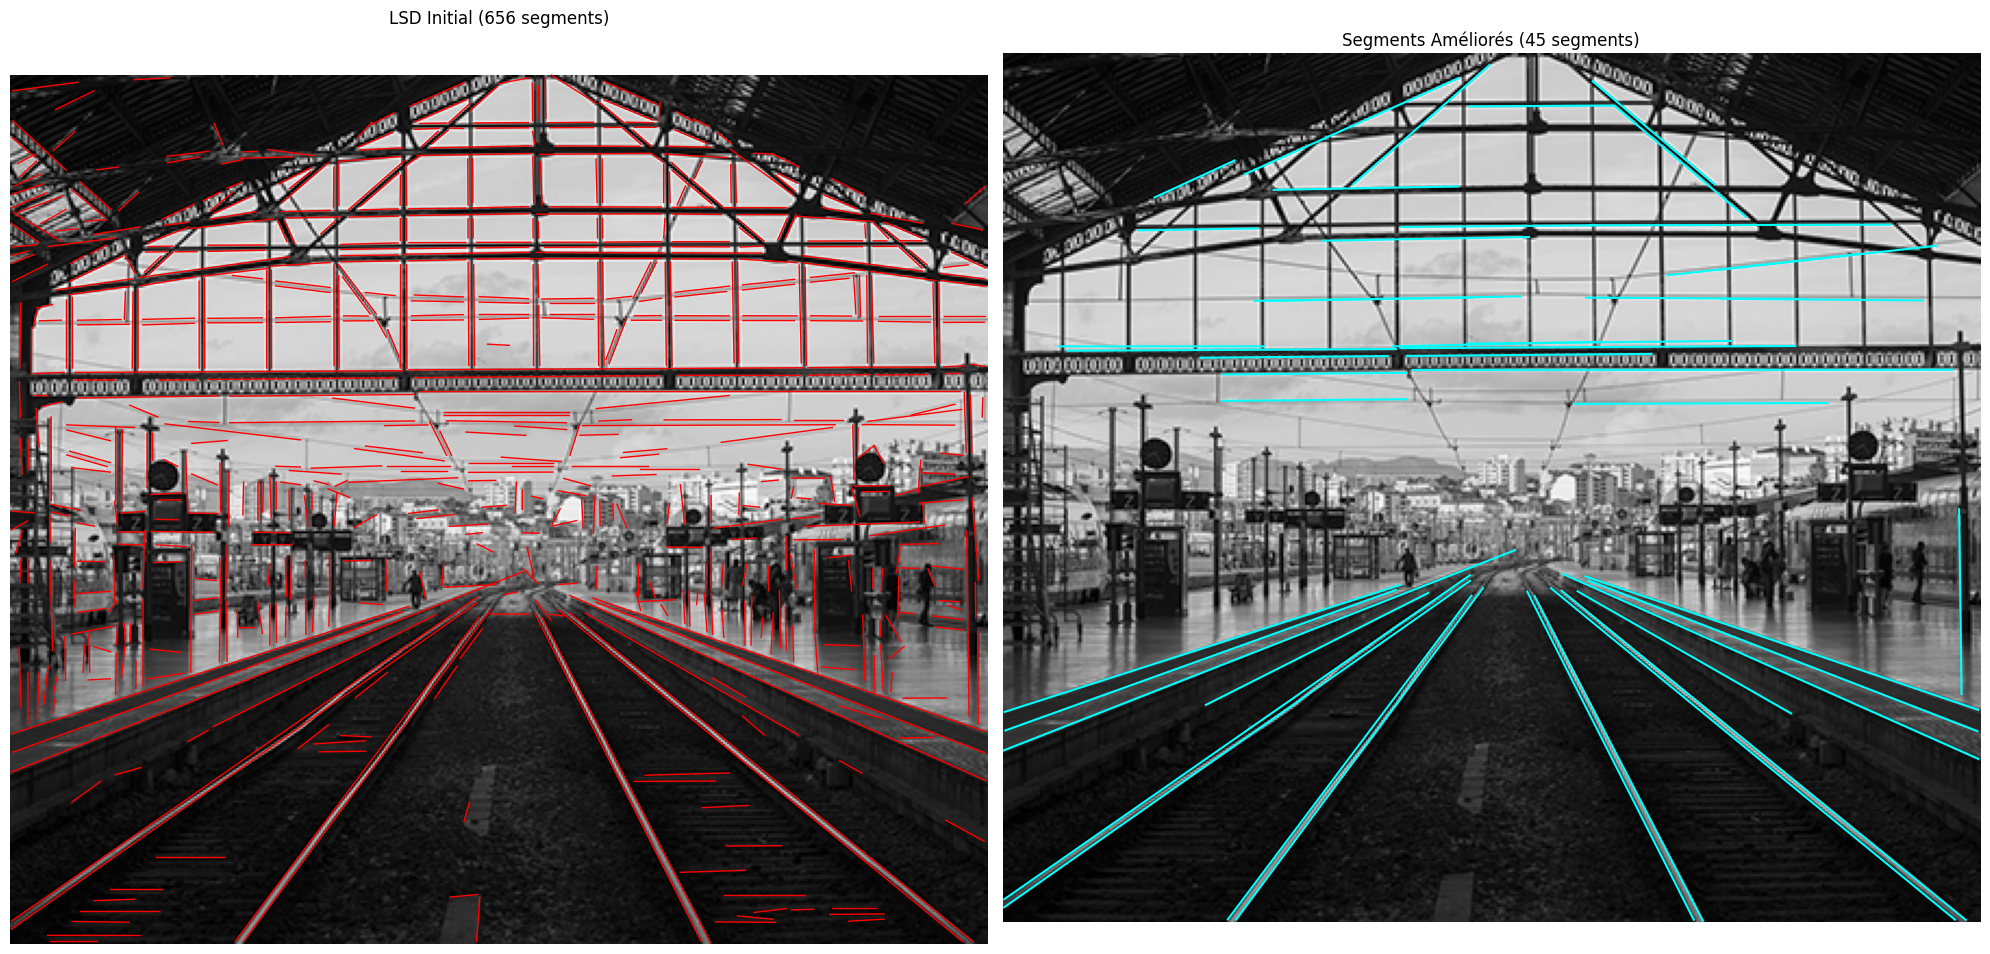

In [ ]:
import matplotlib.pyplot as plt
#M+A
def visualize_segments(img, initial_lines, improved_lines):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Affichage des segments initiaux (LSD)
    axes[0].imshow(img, cmap='gray')
    for line in initial_lines:
        x1, y1, x2, y2 = line
        axes[0].plot([x1, x2], [y1, y2], color='red', linewidth=1)
    axes[0].set_title(f"LSD Initial ({len(initial_lines)} segments)")
    axes[0].axis('off')

    # Affichage des segments améliorés (A Contrario)
    axes[1].imshow(img, cmap='gray')
    for line in improved_lines:
        x1, y1, x2, y2 = line
        axes[1].plot([x1, x2], [y1, y2], color='cyan', linewidth=1.5)
    axes[1].set_title(f"Segments Améliorés ({len(improved_lines)} segments)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Utilisation
visualize_segments(img, lines, final_segments)

Modification 04/03

In [ ]:
#M
# -----------------------------
# Transformations PClines
# -----------------------------
def point_to_dual_straight(A, d=1):
    """
    Transforme un point A=(x,y) en ligne dans le dual space (straight)
    Ligne passant par (0,x) et (d,y)
    """
    x, y = A
    # On renvoie (slope, intercept) de la ligne u -> v : v = m*u + b
    m = (y - x) / d
    b = x
    return m, b

def point_to_dual_twisted(A, d=1):
    """
    Transforme un point A=(x,y) en ligne dans le dual space (twisted)
    Ligne passant par (0,x) et (d,-y)
    """
    x, y = A
    m = (-y - x) / d
    b = x
    return m, b

# -----------------------------
# Intersection de deux lignes dans dual space
# -----------------------------
def intersect_lines_dual(line1, line2):
    m1, b1 = line1
    m2, b2 = line2
    if m1 == m2:
        return None  # lignes parallèles → pas d'intersection
    u = (b2 - b1) / (m1 - m2)
    v = m1 * u + b1
    return np.array([u, v])

def get_line_params(p1, p2):
    """Calcule la pente m et l'intercept b pour v = mu + b."""
    u1, v1 = p1
    u2, v2 = p2
    if abs(u2 - u1) < 1e-10:
        return np.inf, u1 # Cas vertical
    m = (v2 - v1) / (u2 - u1)
    b = v1 - m * u1
    return m, b

# -----------------------------
# Transformation des segments en points dual space
# -----------------------------
def segments_to_dual_points(segments, img_w, img_h, transform='straight', d=1):
    """
    CONFORME SECTION 2.3 : Transforme les segments en points dual space 
    avec normalisation par S = max(W, H).
    """
    points_dual = []
    
    # 1. Calcul du facteur de normalisation S (Tableau 1 du papier)
    S = max(img_w, img_h)
    
    # Définition des domaines bornés selon l'article
    if transform == 'straight':
        domain_u = [-1, 2]
        domain_v = [-1, 2]
    else: # twisted
        domain_u = [-2, 1]
        domain_v = [-2, 1]

    for seg in segments:
        # 2. Normalisation des coordonnées entre 0 et 1
        A = seg[:2] / S
        B = seg[2:] / S
        
        # Transformer chaque endpoint normalisé en ligne dual space
        if transform == 'straight':
            l1 = point_to_dual_straight(A, d)
            l2 = point_to_dual_straight(B, d)
        else:
            l1 = point_to_dual_twisted(A, d)
            l2 = point_to_dual_twisted(B, d)
            
        # 3. Intersection -> point dual unique pour le segment
        pt = intersect_lines_dual(l1, l2)
        
        if pt is not None:
            u, v = pt
            # 4. Vérification stricte du domaine borné
            if domain_u[0] <= u <= domain_u[1] and domain_v[0] <= v <= domain_v[1]:
                points_dual.append(pt)
                
    return np.array(points_dual)

def dual_alignment_to_vp(alignment, S, transform='straight', d=1):
    """
    CORRECTION 3 : Convertit un alignement dual en coordonnées (x, y) image.
    alignment : l'objet dictionnaire retourné par point_alignment_detector.
    """
    p1, p2 = alignment['pair']
    m, b = get_line_params(p1, p2)
    
    # x correspond à l'ordonnée à l'origine (intercept b)
    vx_norm = b
    
    # y dépend de la pente et du type d'espace
    if transform == 'straight':
        # v = ((y-x)/d) * u + x  => m = (y-x)/d
        vy_norm = m * d + vx_norm
    else: # twisted
        # v = ((-y-x)/d) * u + x => m = (-y-x)/d
        vy_norm = -(m * d + vx_norm)
        
    # Retour aux pixels réels de l'image
    return vx_norm * S, vy_norm * S

from scipy.stats import binom

def point_alignment_detector_VP(points, epsilon=1):
    """
    Specialized detector for Vanishing Points in PClines dual space.
    Returns a list of dictionaries to maintain compatibility with conversion functions.
    """
    N = len(points)
    candidates = []
    # Parameters for multi-scale testing in dual space
    W, L, C = 1,1, 1
    total_tests = (N * (N - 1) / 2) * W * L * C 

    for i in range(N):
        for j in range(i + 1, N):
            pt1, pt2 = points[i], points[j]
            dist = np.linalg.norm(pt2 - pt1)
            if dist < 1e-10: continue
            
            # Fine width for angular precision in VP detection
            rect_w = dist * 0.03
            # Use your existing longitudinal counting function
            b_obs = count_points_in_box(points, pt1, pt2, rect_w, 16)
            
            # Local density estimation (q/R) for a-contrario validation
            q = (1/16) / (1.2 * 1.2) 
            p_local = 1 - (1 - q)**N

            # A-contrario validation using the binomial tail
            proba_tail = binom.sf(b_obs - 1, 16, p_local)
            if proba_tail > 0:
                logNFA = np.log10(total_tests) + np.log10(proba_tail)
                # Filter by meaningfulness threshold
                if logNFA <= np.log10(epsilon):
                    candidates.append({
                        'pair': [pt1, pt2], 
                        'logNFA': logNFA
                    })

    # Return top 10 most meaningful VPs (lowest NFA)
    return sorted(candidates, key=lambda x: x['logNFA'])[:10]

from scipy.stats import binom

def point_alignment_detector_VP(points, epsilon=1):
    """
    Specialized detector for Vanishing Points in PClines dual space.
    Returns a list of dictionaries to maintain compatibility with conversion functions.
    """
    N = len(points)
    candidates = []
    # Parameters for multi-scale testing in dual space
    W, L, C = 3, 3, 1
    total_tests = (N * (N - 1) / 2) * W * L * C 

    for i in range(N):
        for j in range(i + 1, N):
            pt1, pt2 = points[i], points[j]
            dist = np.linalg.norm(pt2 - pt1)
            if dist < 1e-10: continue
            
            # Fine width for angular precision in VP detection
            rect_w = dist * 0.03
            # Use your existing longitudinal counting function
            b_obs = count_points_in_box(points, pt1, pt2, rect_w, 16)
            
            # Local density estimation (q/R) for a-contrario validation
            q = (1/16) / (1.2 * 1.2) 
            p_local = 1 - (1 - q)**N

            # A-contrario validation using the binomial tail
            proba_tail = binom.sf(b_obs - 1, 16, p_local)
            if proba_tail > 0:
                logNFA = np.log10(total_tests) + np.log10(proba_tail)
                # Filter by meaningfulness threshold
                # if logNFA <= np.log10(epsilon):
                #     candidates.append({
                #         'pair': [pt1, pt2], 
                #         'logNFA': logNFA
                #     })
                # Modifiez temporairement cette ligne dans point_alignment_detector_VP :
                if True: # On accepte tout pour voir les logNFA calculés
                    candidates.append({'pair': [pt1, pt2], 'logNFA': logNFA})

    # Return top 10 most meaningful VPs (lowest NFA)
    return sorted(candidates, key=lambda x: x['logNFA'])[:10]


def detect_vanishing_points(final_segments, img_w, img_h, epsilon=1):
    """
    Full VP detection pipeline using Straight and Twisted PClines.
    """
    S = max(img_w, img_h)
    # Normalized PClines transformation
    pts_S = segments_to_dual_points(final_segments, img_w, img_h, transform='straight')
    pts_T = segments_to_dual_points(final_segments, img_w, img_h, transform='twisted')
    
    # Run specialized dual-space detector
    vps_S = point_alignment_detector_VP(pts_S, epsilon)
    vps_T = point_alignment_detector_VP(pts_T, epsilon)
    
    return vps_S, vps_T, S

# # -----------------------------
# # Détection des VPs
# # -----------------------------
# def detect_vanishing_points(final_segments, img_w, img_h, c_list=[16], W=3, L=3, C=1, epsilon=1):
#     """
#     CORRECTION 2 : Signature et appel conformes au détecteur a-contrario corrigé.
#     On utilise c=16 car le papier recommande une résolution plus fine pour les VPs.
#     """
#     # 1. Obtenir les points duaux normalisés (Correction 1)
#     # On passe img_w et img_h pour la normalisation interne
#     points_straight = segments_to_dual_points(final_segments, img_w, img_h, transform='straight')
#     points_twisted = segments_to_dual_points(final_segments, img_w, img_h, transform='twisted')

#     # 2. Détection des alignements dans le dual
#     # IMPORTANT : La signature ne prend plus R_area et box_area (calculés en interne)
#     # On capture les objets complets pour avoir accès au logNFA et aux indices
#     vp_alignments_straight = point_alignment_detector(points_straight, c_list, W, L, C, epsilon)
#     vp_alignments_twisted = point_alignment_detector(points_twisted, c_list, W, L, C, epsilon)

#     return vp_alignments_straight, vp_alignments_twisted, max(img_w, img_h)


# def detect_vanishing_points_final(final_segments, img_w, img_h, epsilon=1):
#     # 1. Points duaux normalisés
#     pts_S = segments_to_dual_points(final_segments, img_w, img_h, 'straight')
#     pts_T = segments_to_dual_points(final_segments, img_w, img_h, 'twisted')
#     S = max(img_w, img_h)
    
#     # 2. Détection NFA (Correction 2 appliquée)
#     aligns_S = point_alignment_detector(pts_S, c_list=[16], epsilon=epsilon)
#     aligns_T = point_alignment_detector(pts_T, c_list=[16], epsilon=epsilon)
    
#     final_vps = []
    
#     # 3. Conversion inverse (Correction 3)
#     for a in aligns_S:
#         vx, vy = dual_alignment_to_vp(a, S, 'straight')
#         final_vps.append([vx, vy, a['logNFA']])
        
#     for a in aligns_T:
#         vx, vy = dual_alignment_to_vp(a, S, 'twisted')
#         final_vps.append([vx, vy, a['logNFA']])
        
#     return np.array(final_vps)


In [ ]:
#A
def point_to_dual_straight(A, d=1):
    x, y = A
    m = (y - x) / d
    b = x
    return m, b

def point_to_dual_twisted(A, d=1):
    x, y = A
    m = (-y - x) / d
    b = x
    return m, b

def intersect_lines_dual(line1, line2):
    m1, b1 = line1
    m2, b2 = line2
    if abs(m1 - m2) < 1e-10: return None
    u = (b2 - b1) / (m1 - m2)
    v = m1 * u + b1
    return np.array([u, v])

def get_line_params(p1, p2):
    u1, v1 = p1
    u2, v2 = p2
    if abs(u2 - u1) < 1e-10: return np.inf, u1
    m = (v2 - v1) / (u2 - u1)
    b = v1 - m * u1
    return m, b

# -----------------------------
# 3. Passage au Domaine Dual
# -----------------------------
def segments_to_dual_points(segments, img_w, img_h, transform='straight', d=1):
    points_dual = []
    S = max(img_w, img_h)
    
    if transform == 'straight':
        domain_u, domain_v = [-1, 2], [-1, 2]
    else:
        domain_u, domain_v = [-2, 1], [-2, 1]

    for seg in segments:
        A, B = seg[:2] / S, seg[2:] / S
        if transform == 'straight':
            l1, l2 = point_to_dual_straight(A, d), point_to_dual_straight(B, d)
        else:
            l1, l2 = point_to_dual_twisted(A, d), point_to_dual_twisted(B, d)
            
        pt = intersect_lines_dual(l1, l2)
        if pt is not None:
            u, v = pt
            if domain_u[0] <= u <= domain_u[1] and domain_v[0] <= v <= domain_v[1]:
                points_dual.append(pt)
                
    return np.array(points_dual)

# -----------------------------
# 4. Détecteur VP (PClines Alignments)
# -----------------------------
def point_alignment_detector_VP(points, W=1, L=1, C=1, epsilon=0.01):
    N = len(points)
    if N < 2: return []
    candidates = []
    
    # Paramètre c fixe (résolution de l'alignement dual) ou liste si C > 1
    c_val = 16 
    DUAL_AREA = 9.0 # Domaine de 3x3

    for i in range(N):
        for j in range(i + 1, N):
            pt1, pt2 = points[i], points[j]
            dist = np.linalg.norm(pt2 - pt1)
            if dist < 1e-10: continue
            
            best_nfa = np.inf
            
            # Recherche multi-paramètres
            for w_factor in np.linspace(0.01, 0.03, W):
                rect_w = dist * w_factor
                
                # On pourrait ajouter la boucle L ici pour décaler le rectangle perpendiculairement
                # Pour le VP dual, on reste souvent centré car les points sont précis
                
                # Calcul de p_local (Géométrie de la boîte dans le dual)
                box_area = (dist * rect_w) / c_val
                q = box_area / DUAL_AREA
                p_local = 1 - (1 - q)**N
                p_local = np.clip(p_local, 1e-6, 0.9)

                # Appel à TA fonction compute_logNFA
                b_obs = count_points_in_box(points, pt1, pt2, rect_w, c_val)
                lognfa = compute_logNFA(b_obs, c_val, p_local, N, W, L, C)
                
                if lognfa < best_nfa:
                    best_nfa = lognfa

            if best_nfa <= np.log(epsilon):
                candidates.append({'pair': [pt1, pt2], 'logNFA': best_nfa})

    return sorted(candidates, key=lambda x: x['logNFA'])[:10]

# -----------------------------
# 5. Conversion et Fusion
# -----------------------------
def dual_alignment_to_vp(alignment, S, transform='straight', d=1):
    p1, p2 = alignment['pair']
    m, b = get_line_params(p1, p2)
    vx_norm = b
    if transform == 'straight':
        vy_norm = m * d + vx_norm
    else:
        vy_norm = -(m * d + vx_norm)
    return vx_norm * S, vy_norm * S

def detect_vanishing_points(final_segments, img_w, img_h, W=3, L=3, C=1, epsilon=1):
    S = max(img_w, img_h)
    
    pts_S = segments_to_dual_points(final_segments, img_w, img_h, transform='straight')
    pts_T = segments_to_dual_points(final_segments, img_w, img_h, transform='twisted')
    
    vps_S_raw = point_alignment_detector_VP(pts_S, W, L, C, epsilon)
    vps_T_raw = point_alignment_detector_VP(pts_T, W, L, C, epsilon)
    
    final_vps = []
    # Fusion identique à la logique précédente pour éviter les doublons S/T
    for align in vps_S_raw:
        coords = dual_alignment_to_vp(align, S, 'straight')
        final_vps.append({'coords': np.array(coords), 'logNFA': align['logNFA']})
        
    for align in vps_T_raw:
        coords = np.array(dual_alignment_to_vp(align, S, 'twisted'))
        if not any(np.linalg.norm(v['coords'] - coords) < (S * 0.02) for v in final_vps):
            final_vps.append({'coords': coords, 'logNFA': align['logNFA']})
            
    return sorted(final_vps, key=lambda x: x['logNFA'])

In [ ]:
#M
# 1. Image dimensions
img_h, img_w = img.shape[:2]

# 2. Detect Vanishing Points
vps_S, vps_T, S_factor = detect_vanishing_points(final_segments, img_w, img_h)

print(f"Nombre de VP détectés (Straight): {len(vps_S)}")
print(f"Nombre de VP détectés (Twisted): {len(vps_T)}")

# 3. Conversion to Image Coordinates
print("\nCoordonnées des VP candidats :")
for a in vps_S:
    vx, vy = dual_alignment_to_vp(a, S_factor, 'straight')
    print(f"VP Straight: x={vx:.2f}, y={vy:.2f} (logNFA={a['logNFA']:.2f})")

for a in vps_T:
    vx, vy = dual_alignment_to_vp(a, S_factor, 'twisted')
    print(f"VP Twisted: x={vx:.2f}, y={vy:.2f} (logNFA={a['logNFA']:.2f})")

ValueError: too many values to unpack (expected 3)

In [ ]:
#A
# 1. Image dimensions
img_h, img_w = img.shape[:2]

# 2. Detect Vanishing Points
vps = detect_vanishing_points(final_segments, img_w, img_h)


# 3. Conversion to Image Coordinates
# --- ÉTAPE FINALE : Affichage des résultats après fusion ---

print(f"Nombre de points de fuite uniques après fusion : {len(vps)}")

for i, vp in enumerate(vps[:10]): # On affiche les 10 meilleurs
    # On extrait les coordonnées du dictionnaire 'vp'
    vx, vy = vp['coords'] 
    
    # On récupère le logNFA
    nfa_val = vp['logNFA']
    
    # Affichage propre
    print(f"VP {i+1} : x={vx:.2f}, y={vy:.2f} (logNFA={nfa_val:.2f})")

Nombre de points de fuite uniques après fusion : 10
VP 1 : x=-10202.75, y=253.74 (logNFA=-45.28)
VP 2 : x=-8989.03, y=231.24 (logNFA=-39.35)
VP 3 : x=-6838.68, y=211.39 (logNFA=-27.18)
VP 4 : x=237.01, y=226.73 (logNFA=-26.87)
VP 5 : x=-8478.44, y=221.78 (logNFA=-25.59)
VP 6 : x=-4132.99, y=176.03 (logNFA=-25.40)
VP 7 : x=-8148.74, y=234.95 (logNFA=-25.35)
VP 8 : x=-5048.36, y=179.19 (logNFA=-25.02)
VP 9 : x=230.30, y=228.88 (logNFA=-24.94)
VP 10 : x=-7453.83, y=202.79 (logNFA=-24.86)


In [ ]:
#M
def visualize_vp_candidates(img, segments, vps_S, vps_T, S):
    plt.figure(figsize=(15, 10))
    plt.imshow(img, cmap='gray')
    ax = plt.gca()
    
    # Couleurs distinctes pour les Straight (Chaudes) et Twisted (Froides)
    colors_S = ['red', 'orange', 'yellow', 'magenta', 'pink']
    colors_T = ['blue', 'cyan', 'lime', 'green', 'purple']
    
    # 1. Tracer les VP Straight
    for i, a in enumerate(vps_S):
        vx, vy = dual_alignment_to_vp(a, S, 'straight')
        col = colors_S[i % len(colors_S)]
        ax.plot(vx, vy, 'x', color=col, markersize=12, mew=3, 
                label=f"S-VP {i} (NFA 10^{a['logNFA']:.1f})")
        
    # 2. Tracer les VP Twisted
    for i, a in enumerate(vps_T):
        vx, vy = dual_alignment_to_vp(a, S, 'twisted')
        col = colors_T[i % len(colors_T)]
        ax.plot(vx, vy, '+', color=col, markersize=14, mew=3, 
                label=f"T-VP {i} (NFA 10^{a['logNFA']:.1f})")

    # 3. Tracer les segments originaux pour voir la convergence
    for seg in segments:
        x1, y1, x2, y2 = seg
        ax.plot([x1, x2], [y1, y2], color='white', alpha=0.3, linewidth=1)

    plt.title("Visualisation des 20 Meilleurs Candidats VP (A-Contario Forcé)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    
    # On définit les limites pour voir le couloir et les points proches
    h, w = img.shape
    plt.xlim(-w*0.2, w*1.2)
    plt.ylim(h*1.2, -h*0.2)
    plt.show()

# Exécution
visualize_vp_candidates(img, final_segments, vps_S, vps_T, S_factor)

NameError: name 'vps_S' is not defined

10


C:\Users\athee\AppData\Local\Temp\ipykernel_1252\3030587023.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(final_vps))


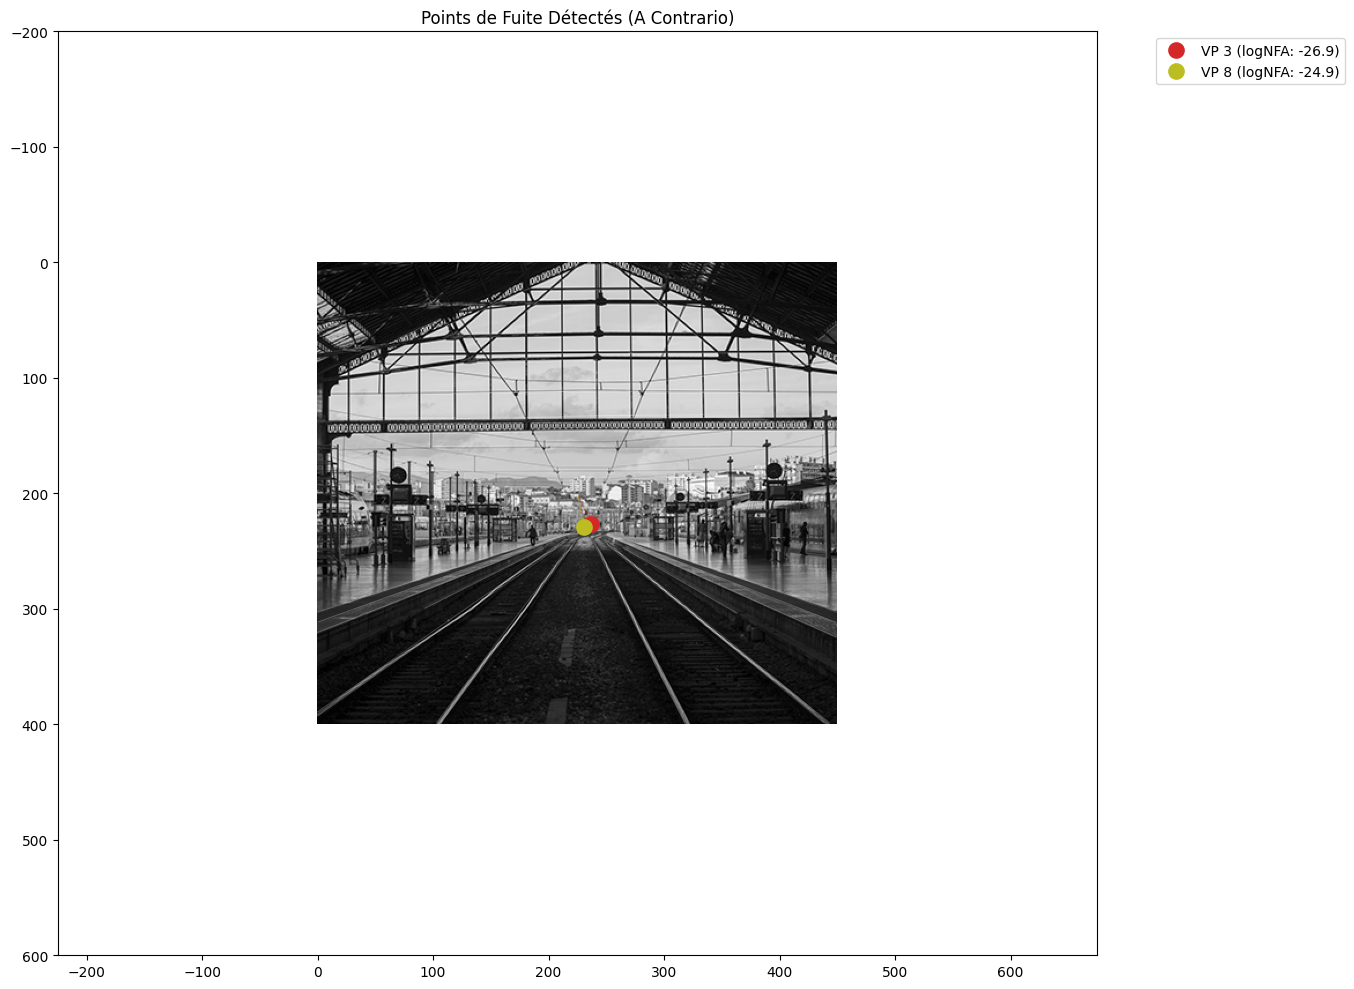

In [ ]:
#A
def visualize_vanishing_points(img, segments, final_vps, img_w, img_h):
    plt.figure(figsize=(15, 10))
    
    # Affichage de l'image de fond
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
        
    ax = plt.gca()
    
    # Palette de couleurs pour les VPs
    colors = plt.cm.get_cmap('tab10', len(final_vps))
    
    # 1. Tracer les segments originaux (en blanc discret)
    for seg in segments:
        ax.plot([seg[0], seg[2]], [seg[1], seg[3]], color='white', alpha=0.2, linewidth=0.8)

    # 2. Tracer chaque VP détecté et ses lignes de convergence
    for i, vp in enumerate(final_vps):
        vx, vy = vp['coords']
        col = colors(i)
        label = f"VP {i} (logNFA: {vp['logNFA']:.1f})"
        
        # On ne dessine le point que s'il n'est pas "trop" à l'infini
        if np.abs(vx) < img_w * 5 and np.abs(vy) < img_h * 5:
            ax.plot(vx, vy, 'o', color=col, markersize=10, mew=2, label=label)
            
            # Tracer une ligne pointillée du centre de l'image vers le VP pour la direction
            ax.annotate("", xy=(vx, vy), xytext=(img_w/2, img_h/2),
                        arrowprops=dict(arrowstyle="->", color=col, linestyle='--', alpha=0.4))

    # 3. Réglage des limites de vue (Zoom intelligent)
    # On laisse un peu de marge autour de l'image pour voir les VP proches
    plt.xlim(-img_w * 0.5, img_w * 1.5)
    plt.ylim(img_h * 1.5, -img_h * 0.5) 
    
    plt.title("Points de Fuite Détectés (A Contrario)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# --- Utilisation ---
vps_result = detect_vanishing_points(final_segments, img_w, img_h)
print(len(vps_result))
visualize_vanishing_points(img, final_segments, vps_result, img_w, img_h)

In [ ]:
#M
all_vps = []

# Conversion des candidats Straight
for a in vps_S:
    vx, vy = dual_alignment_to_vp(a, S_factor, 'straight')
    all_vps.append({'pos': np.array([vx, vy]), 'logNFA': a['logNFA']})

# Conversion des candidats Twisted
for a in vps_T:
    vx, vy = dual_alignment_to_vp(a, S_factor, 'twisted')
    all_vps.append({'pos': np.array([vx, vy]), 'logNFA': a['logNFA']})

# Tri global par significativité (le plus petit NFA en premier)
all_vps = sorted(all_vps, key=lambda x: x['logNFA'])

NameError: name 'vps_S' is not defined

In [ ]:
#M
final_vps = []
dist_threshold = 30  # Tolérance en pixels pour fusionner deux VP proches

for candidate in all_vps:
    is_duplicate = False
    for existing in final_vps:
        # Calcul de la distance euclidienne entre les VP
        dist = np.linalg.norm(candidate['pos'] - existing['pos'])
        if dist < dist_threshold:
            is_duplicate = True
            break
    
    if not is_duplicate:
        final_vps.append(candidate)

# Extraction des coordonnées finales
vps = np.array([v['pos'] for v in final_vps])

print(f"Nombre de points de fuite uniques après fusion : {len(vps)}")
for i, v in enumerate(vps):
    print(f"VP {i} final : x={v[0]:.2f}, y={v[1]:.2f}")

NameError: name 'all_vps' is not defined

In [ ]:
#A
vps_result = detect_vanishing_points(final_segments, img_w, img_h)

# 2. Ton bloc de fusion (Nettoyage des doublons géométriques)
final_vps = []
dist_threshold = 0#5000 # Tolérance en pixels

for candidate in vps_result:
    is_duplicate = False
    # ATTENTION : dans detect_vanishing_points, la clé est 'coords', on l'adapte ici
    candidate_pos = candidate['coords'] 
    
    for existing in final_vps:
        # Calcul de la distance euclidienne entre les VP
        dist = np.linalg.norm(candidate_pos - existing['coords'])
        if dist < dist_threshold:
            is_duplicate = True
            break
    
    if not is_duplicate:
        final_vps.append(candidate)

# 3. Extraction des coordonnées finales
vps = np.array([v['coords'] for v in final_vps])

# 4. Affichage
print(f"Nombre de points de fuite uniques après fusion : {len(vps)}")
for i, v in enumerate(vps):
    print(f"VP {i} final : x={v[0]:.2f}, y={v[1]:.2f}")

Nombre de points de fuite uniques après fusion : 10
VP 0 final : x=-10202.75, y=253.74
VP 1 final : x=-8989.03, y=231.24
VP 2 final : x=-6838.68, y=211.39
VP 3 final : x=237.01, y=226.73
VP 4 final : x=-8478.44, y=221.78
VP 5 final : x=-4132.99, y=176.03
VP 6 final : x=-8148.74, y=234.95
VP 7 final : x=-5048.36, y=179.19
VP 8 final : x=230.30, y=228.88
VP 9 final : x=-7453.83, y=202.79


In [ ]:
def refine_vp_least_squares(segments, vp_candidates, angle_thresh_deg=2):
    """
    Raffinement conforme à la section 2.4 : Moindres carrés sur les segments cohérents.
    """
    #M+A
    refined_vps = []
    
    for vx, vy in vp_candidates:
        A_mat = []
        b_vec = []
        
        for seg in segments:
            x1, y1, x2, y2 = seg
            dx, dy = x2 - x1, y2 - y1
            length = np.hypot(dx, dy)
            
            # 1. Vérification de la cohérence angulaire (tau = 2 degrés dans le papier)
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            vp_dx, vp_dy = vx - cx, vy - cy
            
            angle_seg = np.arctan2(dy, dx)
            angle_vp = np.arctan2(vp_dy, vp_dx)
            diff = np.abs(angle_seg - angle_vp)
            diff = np.minimum(diff, np.pi - diff)
            
            if np.degrees(diff) <= angle_thresh_deg:
                # 2. Équation de la droite : ax + by = c
                # La normale à la droite est (-dy, dx)
                a = -dy
                b = dx
                # Normalisation pour que a^2 + b^2 = 1 (distance orthogonale directe)
                norm = np.hypot(a, b)
                a /= norm
                b /= norm
                c = a * x1 + b * y1
                
                # Pondération par la longueur (les longs segments sont plus fiables)
                A_mat.append([a * length, b * length])
                b_vec.append(c * length)
        
        if len(A_mat) >= 2:
            # 3. Résolution par moindres carrés : A * [vx, vy]^T = b
            A_mat = np.array(A_mat)
            b_vec = np.array(b_vec)
            # lstsq retourne [vx, vy]
            solution, _, _, _ = np.linalg.lstsq(A_mat, b_vec, rcond=None)
            refined_vps.append(solution)
        else:
            refined_vps.append([vx, vy])
            
    return np.array(refined_vps)

In [ ]:
# 1. Préparation des candidats VP (Extraits de vos dictionnaires Straight et Twisted)
# On combine les positions (vx, vy) dans une seule liste pour le raffinement
#M
vp_candidates_raw = []

for a in vps_S:
    vx, vy = dual_alignment_to_vp(a, S_factor, 'straight')
    vp_candidates_raw.append([vx, vy])

for a in vps_T:
    vx, vy = dual_alignment_to_vp(a, S_factor, 'twisted')
    vp_candidates_raw.append([vx, vy])

# 2. Lancement du raffinement par moindres carrés (Section 2.4)
# On utilise les segments améliorés (50 segments) pour la précision mathématique
vps_refined = refine_vp_least_squares(final_segments, vp_candidates_raw, angle_thresh_deg=2.0)

# 3. Conversion en array pour la manipulation facile
vps_refined = np.array(vps_refined)
vps_original = np.array(vp_candidates_raw)

print(f"Raffinement terminé pour {len(vps_refined)} points de fuite.")

NameError: name 'vps_S' is not defined

In [ ]:
#A
vps_raw = np.array([v['coords'] for v in final_vps])

# 2. Raffinement
vps_refined = refine_vp_least_squares(final_segments, vps_raw)

# 3. Mise à jour de tes objets VP pour l'affichage
for i, vp_obj in enumerate(final_vps):
    vp_obj['coords'] = vps_refined[i]
print(vps_refined)

[[353.15036 153.31033]
 [353.15036 153.31033]
 [353.15036 153.31033]
 [351.33182 154.60606]
 [353.15036 153.31033]
 [353.15036 153.31033]
 [353.15036 153.31033]
 [353.15036 153.31033]
 [290.57407 194.0728 ]
 [353.15036 153.31033]]


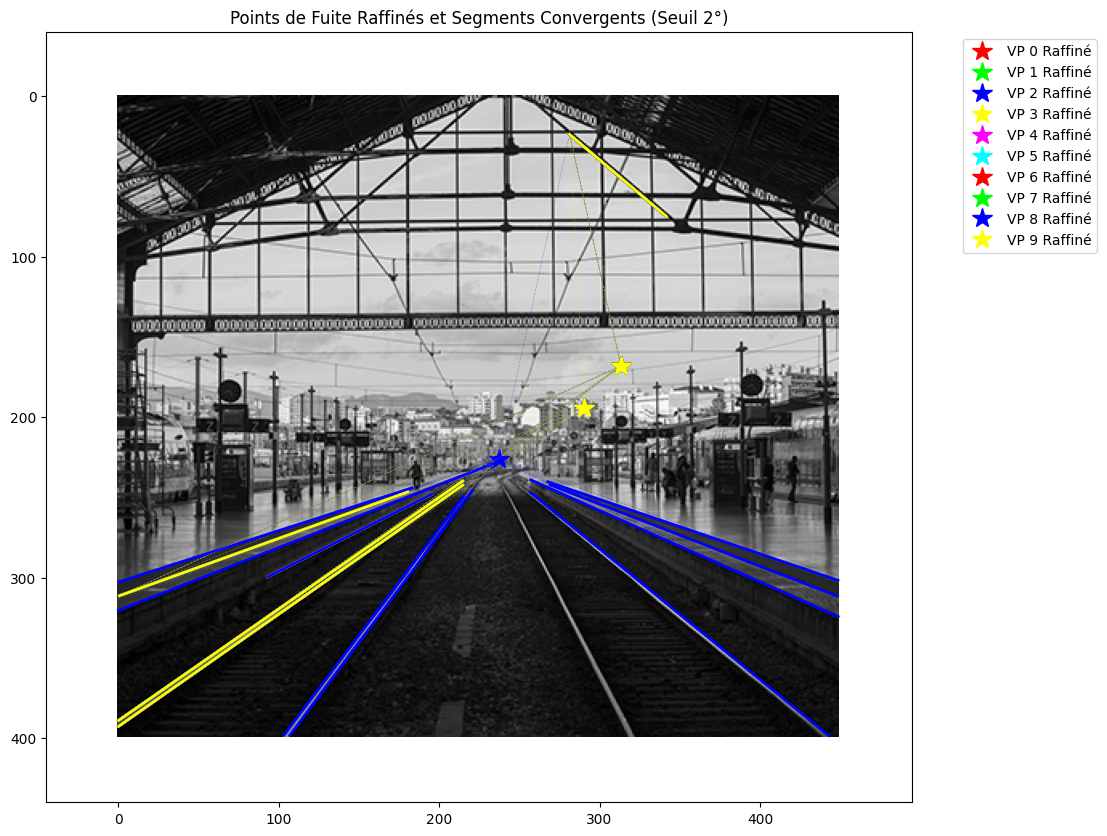

In [ ]:
import matplotlib.pyplot as plt
#M+A

def visualize_refined_vps(img, segments, original_vps, refined_vps):
    plt.figure(figsize=(15, 10))
    plt.imshow(img, cmap='gray')
    ax = plt.gca()
    
    # Couleurs pour les différents VP
    colors = ['red', 'lime', 'blue', 'yellow', 'magenta', 'cyan']
    
    # 1. Affichage des VP (Originaux vs Raffinés)
    for i, (orig, ref) in enumerate(zip(original_vps, refined_vps)):
        col = colors[i % len(colors)]
        
        # VP Original (petit x)
        ax.plot(orig[0], orig[1], 'x', color=col, markersize=8, alpha=0.5)
        
        # VP Raffiné (grosse étoile avec bordure)
        ax.plot(ref[0], ref[1], '*', color=col, markersize=15, mew=1,
                label=f"VP {i} Raffiné")
        
        # 2. Tracer les lignes de convergence pour les segments cohérents
        for seg in segments:
            x1, y1, x2, y2 = seg
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            
            # Calcul de l'angle pour vérifier si le segment appartient à ce VP
            dx, dy = x2 - x1, y2 - y1
            vp_dx, vp_dy = ref[0] - cx, ref[1] - cy
            
            angle_seg = np.arctan2(dy, dx)
            angle_vp = np.arctan2(vp_dy, vp_dx)
            diff = np.abs(angle_seg - angle_vp)
            diff = np.minimum(diff, np.pi - diff)
            
            # Si le segment est cohérent (seuil tau = 2 degrés)
            if np.degrees(diff) <= 2.0:
                # Tracer le segment avec la couleur du VP
                ax.plot([x1, x2], [y1, y2], color=col, linewidth=2)
                # Tracer une ligne pointillée vers le VP pour visualiser la fuite
                ax.plot([x2, ref[0]], [y2, ref[1]], '--', color=col, linewidth=0.5, alpha=0.3)

    plt.title("Points de Fuite Raffinés et Segments Convergents (Seuil 2°)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustement des limites pour voir les VP hors-champ
    h, w = img.shape
    plt.xlim(-w*0.1, w*1.1)
    plt.ylim(h*1.1, -h*0.1)
    plt.show()

# Utilisation : 
# 'vps' sont vos points avant raffinement (convertis en array)
# 'vps_refined' est le résultat de refine_vp_least_squares
visualize_refined_vps(img, final_segments, vps, vps_refined)

In [94]:
# import numpy as np

# def refine_vp(segments, vp_candidates, angle_thresh_deg=10):
#     """
#     segments: Nx4 array [[x1, y1, x2, y2], ...]
#     vp_candidates: list of candidate VPs [[vx, vy, NFA], ...]
#     angle_thresh_deg: seuil pour considérer un segment comme consistant
#     """
#     refined_vps = []
#     for vp in vp_candidates:
#         vx, vy= vp
#         consistent_segments = []
        
#         for seg in segments:
#             x1, y1, x2, y2 = seg
#             # centre du segment
#             cx, cy = (x1+x2)/2, (y1+y2)/2
#             # direction segment
#             dx, dy = x2-x1, y2-y1
#             seg_angle = np.arctan2(dy, dx)
#             # direction centre -> VP
#             vp_dx, vp_dy = vx-cx, vy-cy
#             vp_angle = np.arctan2(vp_dy, vp_dx)
#             # angle entre segment et VP
#             angle_diff = np.abs(seg_angle - vp_angle)
#             angle_diff = np.minimum(angle_diff, np.pi - angle_diff)
            
#             if np.degrees(angle_diff) <= angle_thresh_deg:
#                 consistent_segments.append(seg)
        
#         if len(consistent_segments) > 0:
#             # raffiner VP : moyenne pondérée par longueur des segments
#             points = []
#             weights = []
#             for seg in consistent_segments:
#                 x1, y1, x2, y2 = seg
#                 length = np.hypot(x2-x1, y2-y1)
#                 points.append([x1, y1])
#                 points.append([x2, y2])
#                 weights.extend([length, length])
#             points = np.array(points)
#             weights = np.array(weights)
#             vx_refined = np.average(points[:,0], weights=weights)
#             vy_refined = np.average(points[:,1], weights=weights)
#             refined_vps.append([vx_refined, vy_refined])
#         else:
#             refined_vps.append(vp)
#     return refined_vps

In [95]:
# refined_vps = refine_vp(final_segments, vps, angle_thresh_deg=10)

# print("VP raffinés :")
# for vp in refined_vps:
#     print(f"x={vp[0]:.2f}, y={vp[1]:.2f}")

In [96]:
# def select_final_vp_triplet(vps, gamma=5):
#     """
#     vps : liste de VPs candidats [[x, y, logNFA], ...] ou [[x,y], ...]
#     gamma : tolérance angle orthogonal (deg)
#     """
#     best_triplet = None
#     best_pair = None  # <- important !
#     n = len(vps)
#     vps = np.array(vps)
    
#     # convertir en vecteurs unitaires
#     unit_vecs = np.array([v/np.linalg.norm(v) for v in vps[:,:2]])

#     # test tous les triplets
#     for i in range(n):
#         for j in range(i+1, n):
#             for k in range(j+1, n):
#                 u1, u2, u3 = unit_vecs[i], unit_vecs[j], unit_vecs[k]
#                 angles = [
#                     np.arccos(np.clip(np.dot(u1,u2), -1,1)),
#                     np.arccos(np.clip(np.dot(u1,u3), -1,1)),
#                     np.arccos(np.clip(np.dot(u2,u3), -1,1))
#                 ]
#                 angles_deg = np.degrees(angles)
#                 if all(abs(a - 90) <= gamma for a in angles_deg):
#                     best_triplet = [vps[i], vps[j], vps[k]]
#                     return best_triplet  # on prend le premier valide
    
#     # si aucun triplet, choisir le meilleur couple et cross product
#     if best_triplet is None:
#         for i in range(n):
#             for j in range(i+1, n):
#                 best_pair = [vps[i], vps[j]]
#                 # cross product simplifié
#                 v1, v2 = unit_vecs[i], unit_vecs[j]
#                 v3 = np.cross(np.append(v1,0), np.append(v2,0))
#                 norm_v3 = np.linalg.norm(v3)
#                 if norm_v3 > 0:
#                     v3 /= norm_v3
#                     best_triplet = [best_pair[0], best_pair[1], [v3[0], v3[1], 0]]
#                 else:
#                     best_triplet = [best_pair[0], best_pair[1], [0,0,0]]
#                 return best_triplet
    
#     return best_triplet

In [ ]:
#M

def select_final_vp_triplet(vps_refined, img_w, img_h, gamma=5):
    """
    CONFORME SECTION 2.5 : Sélectionne le triplet de VP le plus orthogonal en 3D.
    vps_refined : Liste de points de fuite [x, y] après raffinement.
    gamma : Tolérance d'orthogonalité en degrés.
    """
    n = len(vps_refined)
    if n < 2:
        return vps_refined

    # 1. Définition de la matrice de calibration K (Estimation standard)
    # On suppose le point principal au centre et une focale f approx.
    f = max(img_w, img_h)  # Estimation courante de la focale
    px, py = img_w / 2, img_h / 2
    K = np.array([
        [f, 0, px],
        [0, f, py],
        [0, 0, 1]
    ])
    K_inv = np.linalg.inv(K)

    # 2. Conversion des VP (pixels) en directions unitaires 3D
    directions = []
    for vp in vps_refined:
        v_homog = np.array([vp[0], vp[1], 1.0])
        d = K_inv @ v_homog
        directions.append(d / np.linalg.norm(d))
    directions = np.array(directions)

    best_triplet = None
    min_ortho_error = float('inf')

    # 3. Test de tous les triplets possibles (Manhattan World)
    for i in range(n):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                d1, d2, d3 = directions[i], directions[j], directions[k]
                
                # Calcul des angles entre les paires (dot product)
                cos_12 = np.abs(np.dot(d1, d2))
                cos_13 = np.abs(np.dot(d1, d3))
                cos_23 = np.abs(np.dot(d2, d3))
                
                # Erreur totale par rapport à l'orthogonalité (cos(90)=0)
                total_error = cos_12 + cos_13 + cos_23
                
                # Vérification de la tolérance gamma
                angles_deg = np.degrees(np.arccos(np.clip([cos_12, cos_13, cos_23], 0, 1)))
                if all(abs(a - 90) <= gamma for a in angles_deg):
                    if total_error < min_ortho_error:
                        min_ortho_error = total_error
                        best_triplet = [vps_refined[i], vps_refined[j], vps_refined[k]]

    # 4. Si aucun triplet, chercher la meilleure paire orthogonale (X, Y)
    if best_triplet is None:
        best_pair_error = float('inf')
        for i in range(n):
            for j in range(i + 1, n):
                error = np.abs(np.dot(directions[i], directions[j]))
                # On sature la valeur entre -1 et 1 pour éviter l'erreur arccos
                error_clipped = np.clip(error, -1.0, 1.0)
                angle_deg = np.degrees(np.arccos(abs(error_clipped)))

                if error < best_pair_error and angle_deg >= (90 - gamma):
                    best_pair_error = error
                    # On peut déduire le 3ème VP par produit vectoriel si nécessaire
                    v3_dir = np.cross(directions[i], directions[j])
                    v3_dir /= np.linalg.norm(v3_dir)
                    # Projection inverse pour obtenir des coordonnées pixels (homographie)
                    v3_pixel = K @ v3_dir
                    v3_pixel = v3_pixel[:2] / v3_pixel[2]
                    best_triplet = [vps_refined[i], vps_refined[j], v3_pixel]

    return best_triplet if best_triplet is not None else vps_refined[:3]

In [ ]:
#M
def select_robust_manhattan_triplet(segments, vps_refined, img_w, img_h, gamma=10):
    """
    Sélectionne le triplet en commençant par le VP ayant le plus de segments (Axe Z).
    """
    if len(vps_refined) < 2: return vps_refined

    # 1. Calcul de la robustesse (score) pour chaque VP
    vp_scores = []
    for vp in vps_refined:
        score = 0
        for seg in segments:
            x1, y1, x2, y2 = seg
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            dx, dy = x2 - x1, y2 - y1
            vp_dx, vp_dy = vp[0] - cx, vp[1] - cy
            diff = np.abs(np.arctan2(dy, dx) - np.arctan2(vp_dy, vp_dx))
            if np.degrees(np.minimum(diff, np.pi - diff)) <= 2.0:
                score += np.hypot(dx, dy)
        vp_scores.append(score)

    # 2. Le VP le plus fort est notre Axe Z (Profondeur)
    idx_z = np.argmax(vp_scores)
    z_vp = vps_refined[idx_z]

    # 3. Setup de la calibration 3D
    f = 1.2 * max(img_w, img_h) # On augmente un peu la focale pour écarter les axes
    K_inv = np.linalg.inv(np.array([[f, 0, img_w/2], [0, f, img_h/2], [0, 0, 1]]))
    
    def to_3d(vp):
        d = K_inv @ np.array([vp[0], vp[1], 1.0])
        return d / np.linalg.norm(d)

    z_dir = to_3d(z_vp)
    best_triplet = [z_vp, None, None]
    min_error = float('inf')

    # 4. Chercher les deux autres axes les plus orthogonaux à Z
    for i in range(len(vps_refined)):
        if i == idx_z: continue
        for j in range(i + 1, len(vps_refined)):
            if j == idx_z: continue
            
            d1, d2 = to_3d(vps_refined[i]), to_3d(vps_refined[j])
            
            # Calcul des erreurs d'orthogonalité (doit être proche de 0)
            err_z1 = np.abs(np.dot(z_dir, d1))
            err_z2 = np.abs(np.dot(z_dir, d2))
            err_12 = np.abs(np.dot(d1, d2))
            
            total_err = err_z1 + err_z2 + err_12
            if total_err < min_error:
                min_error = total_err
                best_triplet = [vps_refined[i], vps_refined[j], z_vp]

    return best_triplet

In [ ]:
# M
gamma = 10  # tolérance en degrés pour l'orthogonalité
final_vp_triplet = select_final_vp_triplet(vps_refined=vps_refined,img_w=img_w, img_h=img_h, gamma=gamma)

print("Triplet final de VPs :")
for i, vp in enumerate(final_vp_triplet):
    print(f"VP{i+1}: x={vp[0]:.2f}, y={vp[1]:.2f}")

Triplet final de VPs :
VP1: x=234.51, y=162.71
VP2: x=221.46, y=162.54
VP3: x=221.46, y=162.54


In [ ]:

gamma = 10  # tolérance en degrés pour l'orthogonalité
final_vp_triplet = select_robust_manhattan_triplet(segments, vps_refined, img_w, img_h, gamma=gamma)

print("Triplet final de VPs :")
for i, vp in enumerate(final_vp_triplet):
    print(f"VP{i+1}: x={vp[0]:.2f}, y={vp[1]:.2f}")

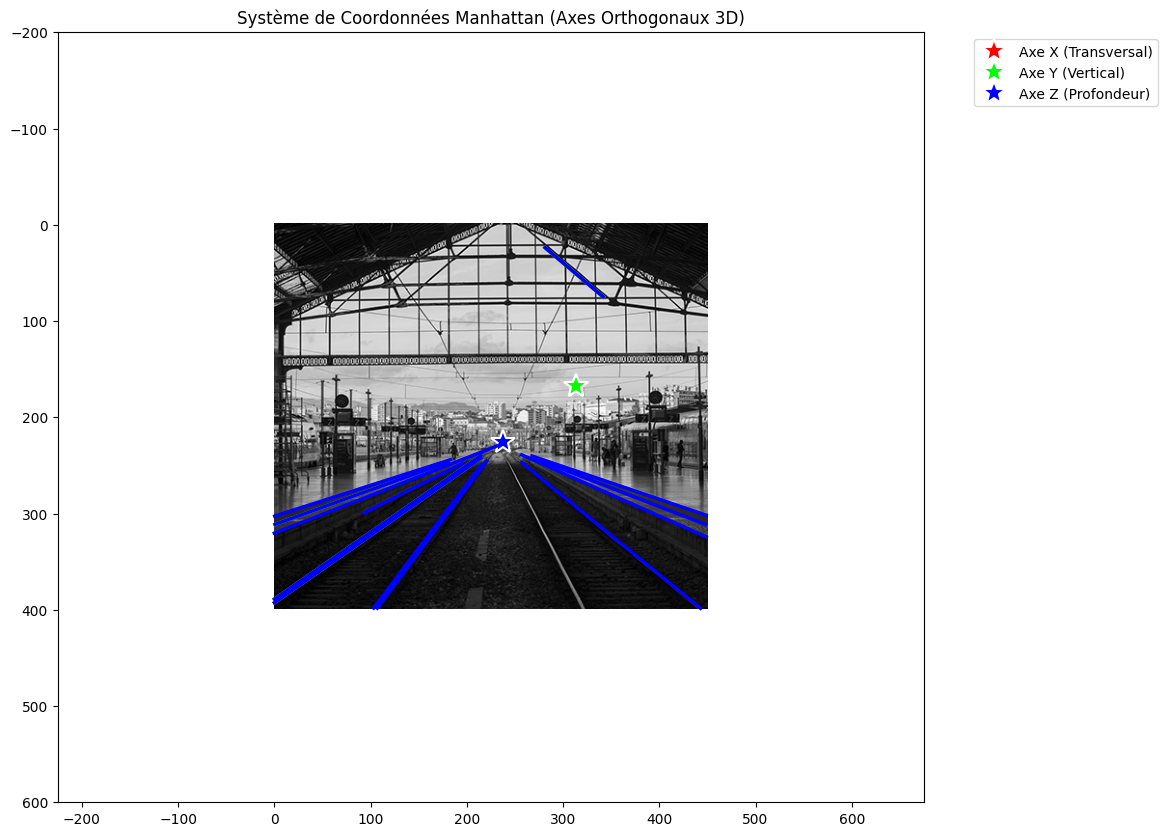

In [ ]:
import matplotlib.pyplot as plt
#M
def visualize_manhattan_triplet(img, segments, final_triplet):
    plt.figure(figsize=(15, 10))
    plt.imshow(img, cmap='gray')
    ax = plt.gca()
    
    # Couleurs conventionnelles pour les axes X, Y, Z
    # Rouge = Horizontal (X), Vert = Vertical (Y), Bleu = Profondeur (Z)
    colors = ['red', 'lime', 'blue']
    labels = ['Axe X (Transversal)', 'Axe Y (Vertical)', 'Axe Z (Profondeur)']
    
    for i, vp in enumerate(final_triplet):
        if vp is None: continue
        
        col = colors[i % len(colors)]
        vx, vy = vp[0], vp[1]
        
        # Affichage du VP (Étoile brillante)
        ax.plot(vx, vy, '*', color=col, markersize=18, markeredgecolor='white', 
                mew=1.5, label=labels[i])
        
        # Identification des segments appartenant à cet axe
        for seg in segments:
            x1, y1, x2, y2 = seg
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            dx, dy = x2 - x1, y2 - y1
            
            vp_dx, vp_dy = vx - cx, vy - cy
            
            angle_seg = np.arctan2(dy, dx)
            angle_vp = np.arctan2(vp_dy, vp_dx)
            diff = np.abs(angle_seg - angle_vp)
            diff = np.minimum(diff, np.pi - diff)
            
            # Seuil de cohérence tau = 2 degrés
            if np.degrees(diff) <= 2.0:
                ax.plot([x1, x2], [y1, y2], color=col, linewidth=2.5)

    plt.title("Système de Coordonnées Manhattan (Axes Orthogonaux 3D)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustement des limites pour capturer les VP à l'infini (ex: axe Vertical)
    h, w = img.shape
    plt.xlim(-w*0.5, w*1.5)
    plt.ylim(h*1.5, -h*0.5)
    plt.show()

# Utilisation
visualize_manhattan_triplet(img, final_segments, final_vp_triplet)

In [ ]:
#A
def get_horizon_line(best_triplet):
    """
    Identifie les deux VP horizontaux et renvoie les paramètres de la droite.
    On suppose que le triplet contient [VP1, VP2, VP_vertical].
    """
    # Dans ta fonction select_robust_manhattan_triplet, le 3ème élément est Z
    vp1, vp2, vp_z = best_triplet
    
    # Équation de la droite passant par vp1 et vp2 : y = ax + b
    x1, y1 = vp1
    x2, y2 = vp2
    
    if abs(x2 - x1) < 1e-10:
        return None # Horizon vertical (très rare, caméra penchée à 90°)
    
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    
    return slope, intercept

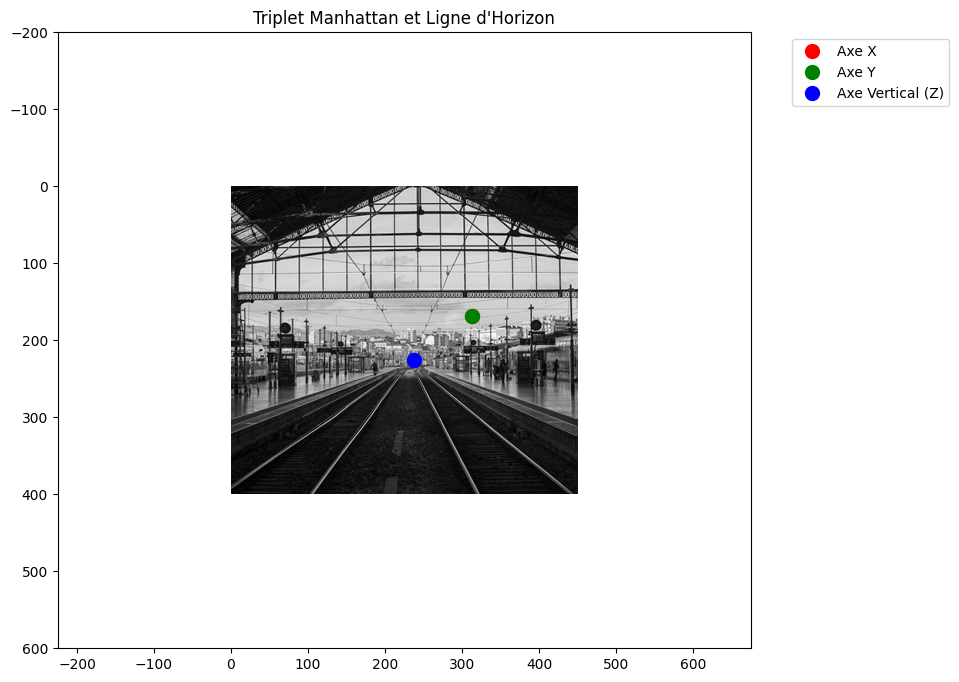

In [ ]:
#A
def plot_horizon(img, segments, best_triplet):
    plt.figure(figsize=(12, 8))
    plt.imshow(img, cmap='gray')
    ax = plt.gca()
    h, w = img.shape[:2]

    # 1. Tracer les segments
    for seg in segments:
        plt.plot([seg[0], seg[2]], [seg[1], seg[3]], color='white', alpha=0.3, lw=0.5)

    # 2. Tracer les 3 VP du triplet
    colors = ['red', 'green', 'blue'] # X, Y, Z
    labels = ['Axe X', 'Axe Y', 'Axe Vertical (Z)']
    for i, vp in enumerate(best_triplet):
        if vp is not None:
            plt.plot(vp[0], vp[1], 'o', color=colors[i], markersize=10, label=labels[i])

    # 3. Tracer l'Horizon (Ligne entre VP[0] et VP[1])
    res = get_horizon_line(best_triplet)
    if res:
        slope, intercept = res
        # On calcule deux points loin à gauche et à droite pour tracer la ligne
        x_vals = np.array([-w*5, w*5])
        y_vals = slope * x_vals + intercept
        plt.plot(x_vals, y_vals, '--', color='yellow', lw=2, label='Ligne d\'Horizon')

    plt.title("Triplet Manhattan et Ligne d'Horizon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # On cadre pour voir l'image et l'horizon proche
    plt.xlim(-w*0.5, w*1.5)
    plt.ylim(h*1.5, -h*0.5)
    plt.show()

# --- UTILISATION ---

plot_horizon(img, final_segments, final_vp_triplet)

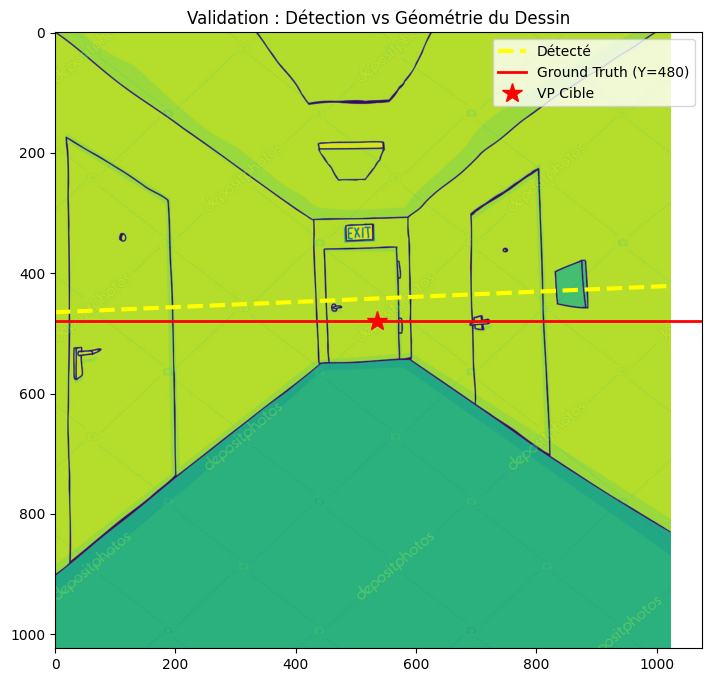

Erreur verticale : 15.11 pixels


In [ ]:
#A POUR C2
def plot_with_absolute_gt(img, best_triplet):
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    h, w = img.shape[:2]
    
    # --- 1. HORIZON DÉTECTÉ (Ton Algorithme) ---
    res = get_horizon_line(best_triplet)
    if res:
        slope, intercept = res
        x_vals = np.array([0, w])
        plt.plot(x_vals, slope * x_vals + intercept, '--', color='yellow', lw=3, label='Détecté')

    # --- 2. GROUND TRUTH (Référence Absolue pour cette image) ---
    # Sur ce dessin, l'horizon est à Y = 480
    gt_y = 480 
    plt.axhline(y=gt_y, color='red', linestyle='-', lw=2, label='Ground Truth (Y=480)')

    # --- 3. POINT DE FUITE CENTRAL (Cible) ---
    # Le VP principal doit être à (535, 480) environ
    plt.plot(535, 480, 'r*', markersize=15, label='VP Cible')

    plt.title("Validation : Détection vs Géométrie du Dessin")
    plt.legend()
    plt.show()

    # Calcul de l'erreur
    if res:
        error_px = abs(res[1] - gt_y) # Erreur en pixels au centre
        print(f"Erreur verticale : {error_px:.2f} pixels")

plot_with_absolute_gt(img,final_vp_triplet)